# Chapter 11: Scoring, Validation & Explanations

End-to-end scoring pipeline with holdout validation, model comparison, adversarial
validation, SHAP explanations, and error analysis.

**Sections:**
1. Run Scoring
2. Summary Metrics
3. Model Comparison Grid
4. Adversarial Pipeline Validation
5. Transformation Validation
6. Model Explanations (SHAP)
7. Customer Browser
8. Error Analysis
9. Export Results

In [1]:
from customer_retention.analysis.notebook_progress import track_and_export_previous

track_and_export_previous("11_scoring_validation.ipynb")

import sys
from pathlib import Path

from customer_retention.core.config.experiments import (  # noqa: F401
    FINDINGS_DIR,
    OUTPUT_DIR,
    setup_experiments_structure,
)

In [2]:
from customer_retention.core.compat.detection import is_databricks
from customer_retention.stages.scoring import ScoringConfig, ScoringDataLoader

if is_databricks():
    config = ScoringConfig.from_databricks()
else:
    generated_dir = Path("../generated_pipelines/local")
    pipeline_dirs = sorted(generated_dir.glob("*/config.py"))
    if not pipeline_dirs:
        raise FileNotFoundError(
            f"No generated pipeline found under {generated_dir}. Run notebook 10 first."
        )
    config = ScoringConfig.from_local_config(pipeline_dirs[-1].parent)

loader = ScoringDataLoader(config)

PIPELINE_NAME = config.pipeline_name
TARGET_COLUMN = config.target_column
ENTITY_KEY = config.entity_key
RECOMMENDATIONS_HASH = config.recommendations_hash
ORIGINAL_COLUMN = config.original_column

print(f"Pipeline: {PIPELINE_NAME}")
print(f"Platform: {'Databricks' if config.is_databricks else 'Local'}")
print(f"Experiments dir: {config.experiments_dir}")
print(f"Recommendations hash: {RECOMMENDATIONS_HASH}")

/Users/Vital/python/CustomerRetention/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pipeline: customer_churn
Platform: Local
Experiments dir: /Users/Vital/python/CustomerRetention/experiments
Recommendations hash: 4131c25b


## 11.1 Run Scoring

In [3]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import numpy as np
import pandas as pd
import xgboost as xgb

from customer_retention.transforms import ArtifactStore, TransformExecutor

_registry = ArtifactStore.from_manifest(Path(config.artifacts_path) / "manifest.yaml")
_executor = TransformExecutor()

ENCODINGS, SCALINGS = loader.load_transforms()

PREDICTIONS_PATH = config.production_dir / "data" / "scoring" / "predictions.parquet"

mlflow.set_tracking_uri(config.mlflow_tracking_uri)

features_df = loader.load_gold_features()

if ORIGINAL_COLUMN not in features_df.columns:
    raise ValueError(
        f"No holdout found (column '{ORIGINAL_COLUMN}' missing). "
        "Holdout must be created in silver layer BEFORE gold layer feature computation."
    )

scoring_mask = features_df[TARGET_COLUMN].isna() & features_df[ORIGINAL_COLUMN].notna()
scoring_df = features_df[scoring_mask].copy()
print(f"Found {len(scoring_df):,} holdout records for scoring")

scoring_features = loader.load_scoring_features(scoring_df)

model, model_uri = loader.load_model()
print(f"Loading model: {model_uri}")


def prepare_features(df):
    return loader.prepare_features(df, ENCODINGS + SCALINGS, _executor, _registry)


X = prepare_features(scoring_features)
y_true = scoring_features[ORIGINAL_COLUMN].values

print("Generating predictions...")
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X)[:, 1]
else:
    y_proba = model.predict(xgb.DMatrix(X, feature_names=list(X.columns)))
y_pred = (y_proba >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else 0.0,
}
print("\nValidation Metrics (vs original values):")
for name, value in metrics.items():
    print(f"  {name}: {value:.4f}")

predictions_df = pd.DataFrame({
    ENTITY_KEY: scoring_df[ENTITY_KEY].values,
    "prediction": y_pred,
    "probability": y_proba,
    "actual": y_true,
    "correct": (y_pred == y_true).astype(int),
})
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
predictions_df.to_parquet(PREDICTIONS_PATH, index=False)
print(f"\nPredictions saved: {PREDICTIONS_PATH}")
print(f"Correct: {predictions_df['correct'].sum():,}/{len(predictions_df):,} ({predictions_df['correct'].mean():.1%})")

Found 499 holdout records for scoring


2026/02/04 21:54:25 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/04 21:54:25 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/04 21:54:25 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/04 21:54:25 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/04 21:54:25 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/04 21:54:25 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/04 21:54:25 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/04 21:54:25 INFO alembic.runtime.migration: Will assume non-transactional DDL.

Loading model: runs:/ac9eb99d79d14b9abb3c75edbe14d2d3/model_logistic_regression_4131c25b
Generating predictions...

Validation Metrics (vs original values):
  accuracy: 0.9960
  precision: 0.6667
  recall: 0.6667
  f1: 0.6667
  roc_auc: 0.9966

Predictions saved: /Users/Vital/python/CustomerRetention/experiments/data/scoring/predictions.parquet
Correct: 497/499 (99.6%)


## 11.2 Summary Metrics

In [4]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

y_true = predictions_df["actual"]
y_pred = predictions_df["prediction"]
y_proba = predictions_df["probability"]

metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1 Score": f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else 0.0,
}

print("\n=== Scoring Validation Metrics ===")
for name, value in metrics.items():
    print(f"  {name}: {value:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")


=== Scoring Validation Metrics ===
  Accuracy: 0.9960
  Precision: 0.6667
  Recall: 0.6667
  F1 Score: 0.6667
  ROC-AUC: 0.9966

Confusion Matrix:
  TN=495  FP=1
  FN=1  TP=2


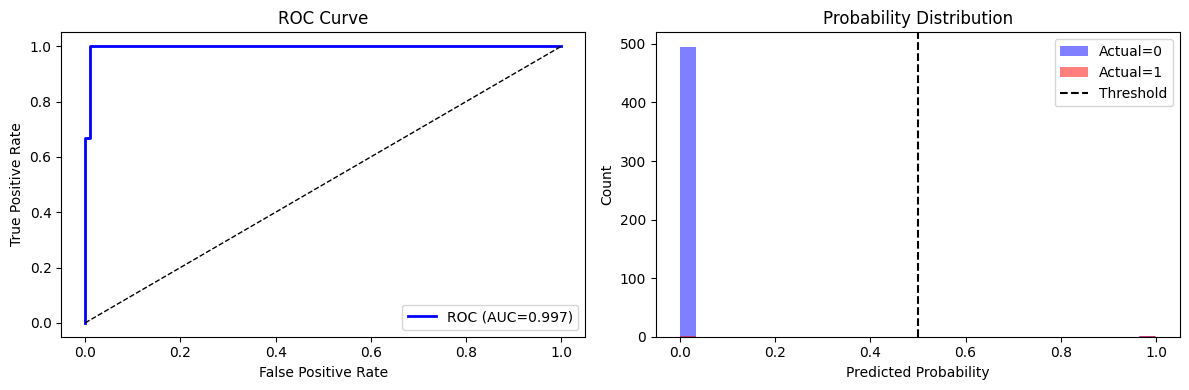

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_proba)
axes[0].plot(fpr, tpr, "b-", lw=2, label=f"ROC (AUC={metrics['ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Probability distribution
axes[1].hist(y_proba[y_true == 0], bins=30, alpha=0.5, label="Actual=0", color="blue")
axes[1].hist(y_proba[y_true == 1], bins=30, alpha=0.5, label="Actual=1", color="red")
axes[1].axvline(x=0.5, color="black", linestyle="--", label="Threshold")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Probability Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11.3 Model Comparison Grid

Compare all trained models (Logistic Regression, Random Forest, XGBoost) on the holdout set.

**Grid Layout:**
- **Row 1**: Confusion matrices (counts and percentages)
- **Row 2**: ROC curves with AUC scores
- **Row 3**: Precision-Recall curves with PR-AUC scores

In [6]:
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

mlflow.set_tracking_uri(config.mlflow_tracking_uri)
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(PIPELINE_NAME)

X_holdout = prepare_features(scoring_features)
y_actual = predictions_df["actual"].values

logged_models = client.search_logged_models(experiment_ids=[experiment.experiment_id])

model_types = ["logistic_regression", "random_forest", "xgboost"]
model_display_names = ["Logistic Regression", "Random Forest", "XGBoost"]
loaded_models = {}
model_predictions = {}

for model_type, display_name in zip(model_types, model_display_names):
    model_name_pattern = f"model_{model_type}"
    if RECOMMENDATIONS_HASH:
        model_name_pattern = f"{model_name_pattern}_{RECOMMENDATIONS_HASH}"

    matching_model = None
    for lm in logged_models:
        if lm.name == model_name_pattern:
            if matching_model is None or lm.creation_timestamp > matching_model.creation_timestamp:
                matching_model = lm

    if matching_model:
        try:
            if "xgboost" in model_type:
                m = mlflow.xgboost.load_model(matching_model.model_uri)
                dmatrix = xgb.DMatrix(X_holdout, feature_names=list(X_holdout.columns))
                yp = m.predict(dmatrix)
            else:
                m = mlflow.sklearn.load_model(matching_model.model_uri)
                yp = m.predict_proba(X_holdout)[:, 1]

            y_p = (yp > 0.5).astype(int)
            loaded_models[display_name] = m
            model_predictions[display_name] = {"y_pred": y_p, "y_proba": yp}
            print(f"Loaded {display_name}: ROC-AUC = {roc_auc_score(y_actual, yp):.4f}")
        except Exception as e:
            print(f"Could not load {display_name}: {e}")

print(f"\nLoaded {len(loaded_models)} models for comparison")

Loaded Logistic Regression: ROC-AUC = 0.9966
Loaded Random Forest: ROC-AUC = 0.9940
Loaded XGBoost: ROC-AUC = 0.9987

Loaded 3 models for comparison


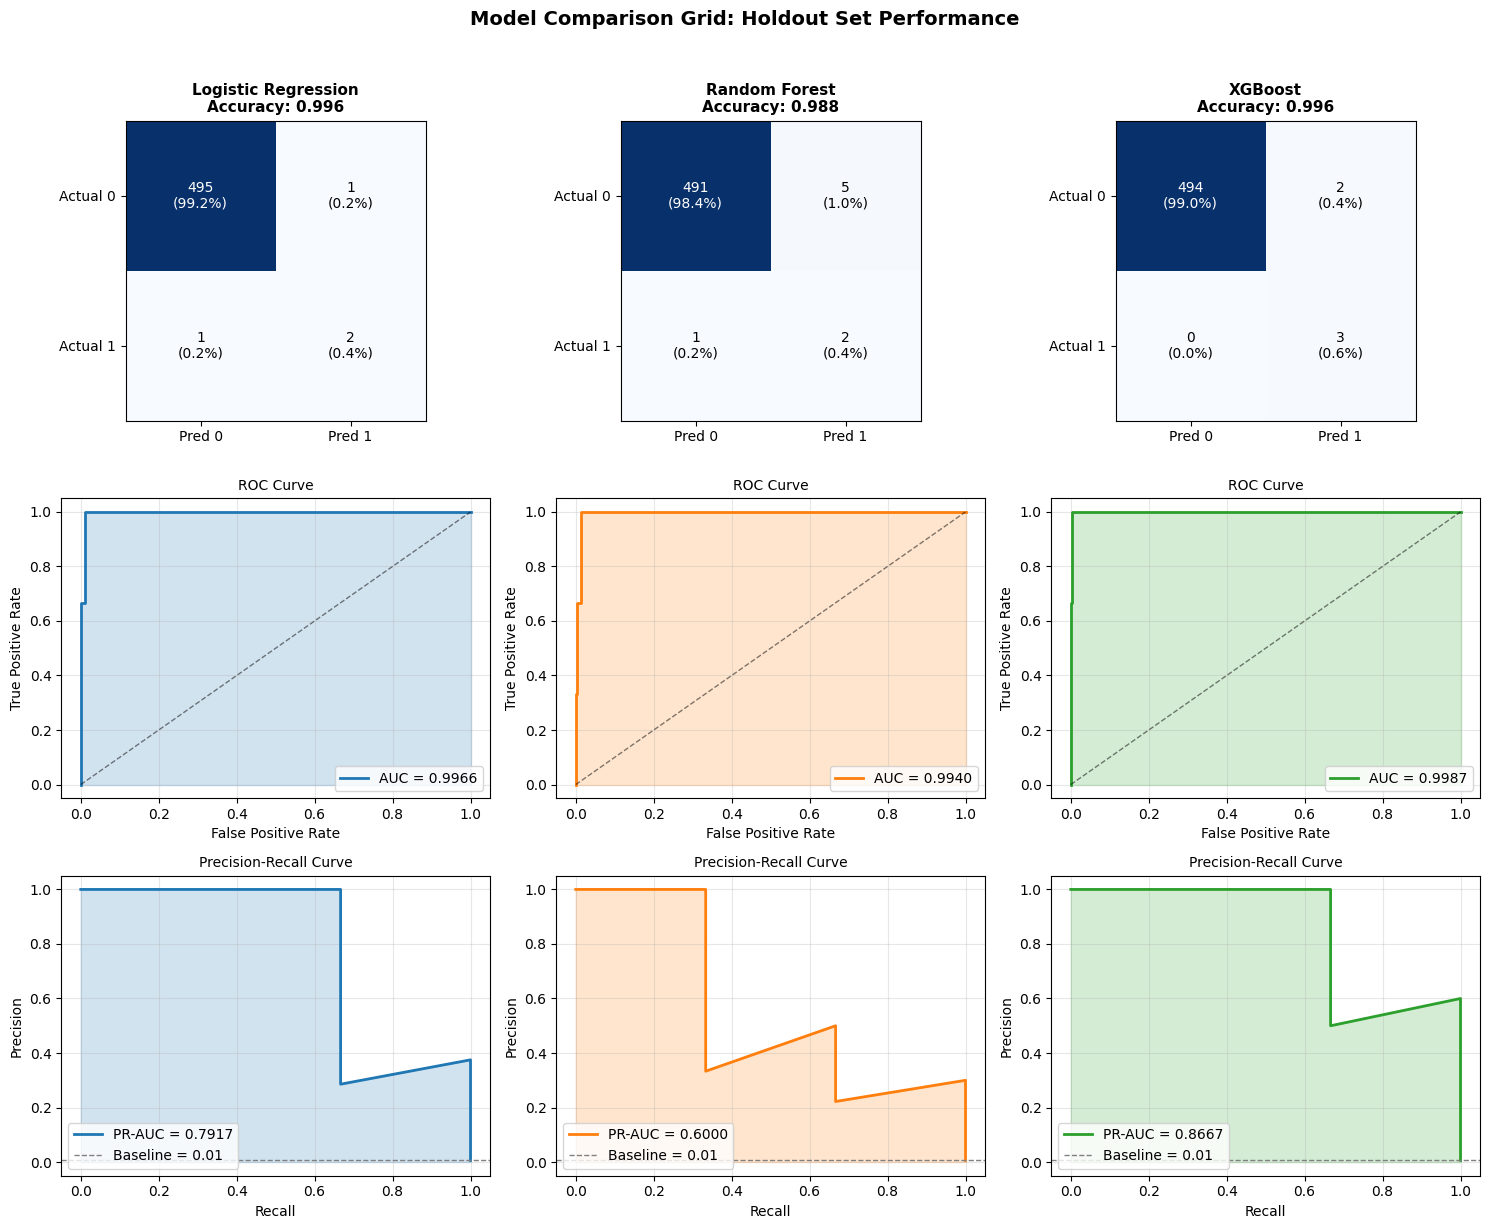

In [7]:
# Model Comparison Grid (3 columns x 3 rows)
n_models = len(model_predictions)
if n_models > 0:
    fig, axes = plt.subplots(3, n_models, figsize=(5 * n_models, 12))
    if n_models == 1:
        axes = axes.reshape(-1, 1)

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for col_idx, (name, preds) in enumerate(model_predictions.items()):
        y_p = preds["y_pred"]
        yp = preds["y_proba"]
        color = colors[col_idx % len(colors)]

        # Row 1: Confusion Matrix
        cm = confusion_matrix(y_actual, y_p)
        ax = axes[0, col_idx]
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticklabels(["Actual 0", "Actual 1"])
        for i in range(2):
            for j in range(2):
                pct = cm[i, j] / cm.sum() * 100
                ax.text(j, i, f"{cm[i, j]}\n({pct:.1f}%)", ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
        acc = accuracy_score(y_actual, y_p)
        ax.set_title(f"{name}\nAccuracy: {acc:.3f}", fontsize=11, fontweight="bold")

        # Row 2: ROC Curve
        ax = axes[1, col_idx]
        fpr, tpr, _ = roc_curve(y_actual, yp)
        auc = roc_auc_score(y_actual, yp)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc:.4f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
        ax.fill_between(fpr, tpr, alpha=0.2, color=color)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title("ROC Curve", fontsize=10)
        ax.legend(loc="lower right")
        ax.grid(True, alpha=0.3)

        # Row 3: Precision-Recall Curve
        ax = axes[2, col_idx]
        precision_vals, recall_vals, _ = precision_recall_curve(y_actual, yp)
        pr_auc = average_precision_score(y_actual, yp)
        ax.plot(recall_vals, precision_vals, color=color, lw=2, label=f"PR-AUC = {pr_auc:.4f}")
        baseline = y_actual.sum() / len(y_actual)
        ax.axhline(y=baseline, color="gray", linestyle="--", lw=1, label=f"Baseline = {baseline:.2f}")
        ax.fill_between(recall_vals, precision_vals, alpha=0.2, color=color)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title("Precision-Recall Curve", fontsize=10)
        ax.legend(loc="lower left")
        ax.grid(True, alpha=0.3)

    plt.suptitle("Model Comparison Grid: Holdout Set Performance",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No models loaded for comparison")

In [8]:
# Summary metrics table for all models
if model_predictions:
    comparison_results = []
    for name, preds in model_predictions.items():
        y_p = preds["y_pred"]
        yp = preds["y_proba"]
        comparison_results.append({
            "Model": name,
            "ROC-AUC": roc_auc_score(y_actual, yp),
            "PR-AUC": average_precision_score(y_actual, yp),
            "F1-Score": f1_score(y_actual, y_p),
            "Precision": precision_score(y_actual, y_p, zero_division=0),
            "Recall": recall_score(y_actual, y_p, zero_division=0),
            "Accuracy": accuracy_score(y_actual, y_p),
        })

    comparison_df = pd.DataFrame(comparison_results).set_index("Model")
    print("\n" + "=" * 70)
    print("MODEL COMPARISON SUMMARY (Holdout Set)")
    print("=" * 70)
    display(
        comparison_df.style
        .highlight_max(axis=0, props="background-color: #2e7d32; color: white")
        .format("{:.4f}")
    )

    best_model_name = comparison_df["ROC-AUC"].idxmax()
    best_auc = comparison_df.loc[best_model_name, "ROC-AUC"]
    print(f"\nBest Model: {best_model_name} (ROC-AUC = {best_auc:.4f})")


MODEL COMPARISON SUMMARY (Holdout Set)


,ROC-AUC,PR-AUC,F1-Score,Precision,Recall,Accuracy
Model,,,,,,
Logistic Regression,0.9966,0.7917,0.6667,0.6667,0.6667,0.9960
Random Forest,0.9940,0.6000,0.4000,0.2857,0.6667,0.9880
XGBoost,0.9987,0.8667,0.7500,0.6000,1.0000,0.9960



Best Model: XGBoost (ROC-AUC = 0.9987)


## 11.4 Adversarial Pipeline Validation

Validate that scoring pipeline produces identical features to training for holdout entities.
This catches transformation inconsistencies (e.g., scalers re-fit, encoders handling unseen values differently).

In [9]:
gold_features = loader.load_gold_features()

holdout_mask = gold_features[ORIGINAL_COLUMN].notna()
holdout_gold = gold_features[holdout_mask].copy()
print(f"Holdout entities for validation: {holdout_mask.sum():,}")

scoring_entity_ids = set(scoring_features[ENTITY_KEY].values)
gold_holdout = holdout_gold[holdout_gold[ENTITY_KEY].isin(scoring_entity_ids)]

exclude_cols = {ENTITY_KEY, config.timestamp_column, TARGET_COLUMN, ORIGINAL_COLUMN}
compare_cols = [
    c for c in gold_holdout.columns
    if c not in exclude_cols and not c.startswith("original_")
]

print("\n" + "=" * 60)
print("ADVERSARIAL PIPELINE VALIDATION")
print("=" * 60)

mismatches = []
for col in compare_cols:
    if col in scoring_features.columns and col in gold_holdout.columns:
        g_vals = gold_holdout[col].values
        s_vals = scoring_features.reindex(gold_holdout.index)[col].values
        if pd.api.types.is_numeric_dtype(gold_holdout[col]):
            delta = np.abs(g_vals.astype(float) - s_vals.astype(float))
            max_delta = np.nanmax(delta) if len(delta) > 0 else 0
            if max_delta > 1e-6:
                mismatches.append({"feature": col, "max_delta": max_delta})

if not mismatches:
    print("\nPASSED: Scoring features match training features")
else:
    print(f"\nFAILED: {len(mismatches)} features with drift")
    display(pd.DataFrame(mismatches).sort_values("max_delta", ascending=False))

Holdout entities for validation: 499

ADVERSARIAL PIPELINE VALIDATION

PASSED: Scoring features match training features


/var/folders/72/y4714p194w93d58ktdfw19500000gq/T/ipykernel_64981/1136319630.py:27: RuntimeWarning: All-NaN slice encountered
  max_delta = np.nanmax(delta) if len(delta) > 0 else 0


## 11.5 Transformation Validation

Use `validate_feature_transformation()` from the validation module to verify
encoding/scaling consistency between training and scoring.

In [10]:
from customer_retention.stages.validation import validate_feature_transformation

training_mask = gold_features[ORIGINAL_COLUMN].isna()
training_subset = gold_features[training_mask].copy()
scoring_subset = gold_features[~training_mask].copy()

report = validate_feature_transformation(
    training_df=training_subset,
    scoring_df=scoring_subset,
    transform_fn=prepare_features,
    entity_column=ENTITY_KEY,
    verbose=True,
)

if report.passed:
    print("Transformation validation PASSED")
else:
    print(f"Transformation validation FAILED: {len(report.feature_mismatches)} mismatches")

Validating transformation consistency...
Transformation validation: PASSED
Transformation validation PASSED


## 11.6 Model Explanations (SHAP)

In [11]:
import shap

mlflow.set_tracking_uri(config.mlflow_tracking_uri)
client = mlflow.tracking.MlflowClient()

experiment = client.get_experiment_by_name(PIPELINE_NAME)
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.best_roc_auc DESC"],
    max_results=1,
)
parent_run = runs[0]

best_model_tag = parent_run.data.tags.get("best_model", "random_forest")
model_name = f"model_{best_model_tag}"
if RECOMMENDATIONS_HASH:
    model_name = f"{model_name}_{RECOMMENDATIONS_HASH}"

child_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run.info.run_id}'",
)
model_run = next((c for c in child_runs if c.info.run_name == best_model_tag), parent_run)

model_uri = f"runs:/{model_run.info.run_id}/{model_name}"
print(f"Loading model: {model_uri}")
if best_model_tag == "xgboost":
    model = mlflow.xgboost.load_model(model_uri)
else:
    model = mlflow.sklearn.load_model(model_uri)
print(f"Model type: {type(model).__name__}")

Loading model: runs:/ac9eb99d79d14b9abb3c75edbe14d2d3/model_logistic_regression_4131c25b


Model type: LogisticRegression


In [12]:
# Prepare features for SHAP using TransformExecutor (NOT LabelEncoder)
X = prepare_features(scoring_features)
feature_names = list(X.columns)
print(f"Prepared {len(feature_names)} features for SHAP analysis")

Prepared 157 features for SHAP analysis


In [13]:
# Create SHAP explainer
print("Creating SHAP explainer (may take a moment)...")

background_size = min(100, len(X))
background = shap.sample(X, background_size)

if hasattr(model, "predict_proba"):
    explainer = shap.Explainer(model.predict_proba, background, feature_names=feature_names)
else:
    explainer = shap.Explainer(model, background, feature_names=feature_names)

print("Computing SHAP values...")
shap_values = explainer(X)
print(f"SHAP values computed for {len(shap_values)} records")

Creating SHAP explainer (may take a moment)...
Computing SHAP values...
SHAP values computed for 499 records


/var/folders/72/y4714p194w93d58ktdfw19500000gq/T/ipykernel_64981/3863259799.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X, feature_names=feature_names, show=False, max_display=20)


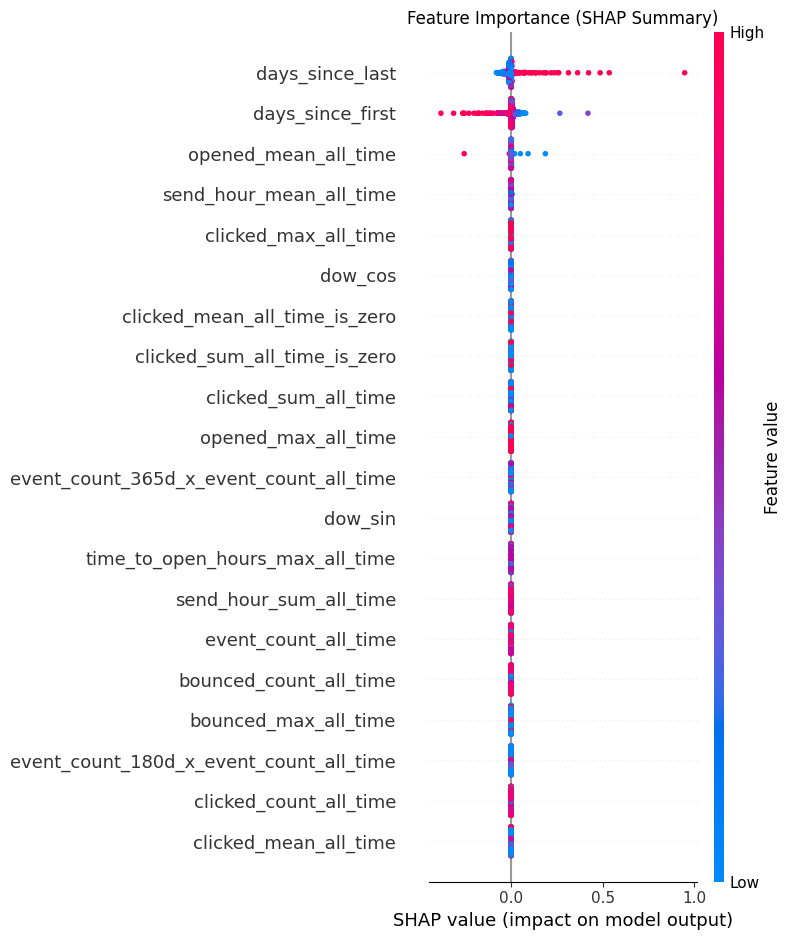

In [14]:
# Use positive class SHAP values if multi-output
if len(shap_values.shape) == 3:
    shap_vals = shap_values[:, :, 1]  # Positive class
else:
    shap_vals = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X, feature_names=feature_names, show=False, max_display=20)
plt.title("Feature Importance (SHAP Summary)")
plt.tight_layout()
plt.show()

In [15]:
# Mean absolute SHAP values
mean_shap = np.abs(shap_vals.values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_shap,
}).sort_values("importance", ascending=False)

print("Top 15 Most Important Features:")
display(importance_df.head(15))

Top 15 Most Important Features:


,feature,importance
120,days_since_last,2.189399e-02
121,days_since_first,1.915021e-02
102,opened_mean_all_time,1.546789e-03
110,send_hour_mean_all_time,2.079616e-05
107,clicked_max_all_time,1.200515e-05
123,dow_cos,1.061003e-05
154,clicked_mean_all_time_is_zero,9.085923e-06
153,clicked_sum_all_time_is_zero,8.907317e-06
105,clicked_sum_all_time,5.512361e-06
103,opened_max_all_time,4.821229e-06


## 11.7 Customer Browser

In [16]:
browser_df = predictions_df.merge(
    scoring_features[[ENTITY_KEY] + feature_names],
    on=ENTITY_KEY,
    how="left",
)

print(f"Customer browser ready with {len(browser_df):,} records")
print("\nPrediction Distribution:")
print(f"  Predicted Positive: {(browser_df['prediction'] == 1).sum():,}")
print(f"  Predicted Negative: {(browser_df['prediction'] == 0).sum():,}")
print(f"\nCorrect Predictions: {browser_df['correct'].sum():,}/{len(browser_df):,} ({browser_df['correct'].mean():.1%})")

Customer browser ready with 499 records

Prediction Distribution:
  Predicted Positive: 3
  Predicted Negative: 496

Correct Predictions: 497/499 (99.6%)


In [17]:
def show_customer(idx: int):
    row = browser_df.iloc[idx]
    entity_id = row[ENTITY_KEY]

    print(f"=== Customer {entity_id} ===")
    print(f"Prediction: {int(row['prediction'])} (probability: {row['probability']:.3f})")
    print(f"Actual: {int(row['actual'])}")
    print(f"Correct: {'Yes' if row['correct'] else 'No'}")
    print()

    feature_vals = X.iloc[idx]
    if len(shap_values.shape) == 3:
        customer_shap = shap_values[idx, :, 1].values
    else:
        customer_shap = shap_values[idx].values

    feature_impact = pd.DataFrame({
        "feature": feature_names,
        "value": feature_vals.values,
        "shap_impact": customer_shap,
    }).sort_values("shap_impact", key=abs, ascending=False)

    print("Top Contributing Features:")
    display(feature_impact.head(10))

    plt.figure(figsize=(10, 6))
    if len(shap_values.shape) == 3:
        shap.plots.waterfall(shap_values[idx, :, 1], max_display=10, show=False)
    else:
        shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"SHAP Explanation for Customer {entity_id}")
    plt.tight_layout()
    plt.show()

Showing first 3 customers:

=== Customer 0091D5 ===
Prediction: 0 (probability: 0.000)
Actual: 0
Correct: Yes

Top Contributing Features:


,feature,value,shap_impact
121,days_since_first,3179.000000,3.529586e-03
102,opened_mean_all_time,7.250272,-1.648060e-03
120,days_since_last,120.000000,-1.595098e-03
110,send_hour_mean_all_time,-10.879783,-1.638239e-04
107,clicked_max_all_time,1.000000,-1.104385e-04
105,clicked_sum_all_time,0.741276,-4.715245e-05
128,event_count_365d_x_event_count_all_time,68.000000,3.055306e-05
126,event_count_180d_x_event_count_all_time,34.000000,7.145622e-06
106,clicked_mean_all_time,0.105464,-4.143006e-06
108,clicked_count_all_time,1.358505,5.938379e-07


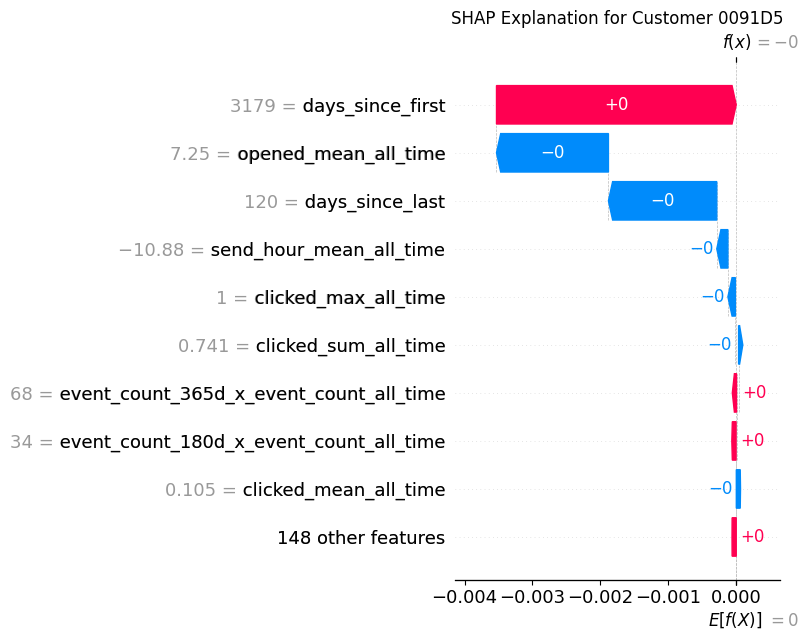



=== Customer 00CAEF ===
Prediction: 0 (probability: 0.000)
Actual: 0
Correct: Yes

Top Contributing Features:


,feature,value,shap_impact
120,days_since_last,2093.000000,-4.985321e-11
121,days_since_first,3208.000000,4.981749e-11
103,opened_max_all_time,0.000000,2.382487e-13
123,dow_cos,0.000000,-2.014002e-13
119,event_count_all_time,1.162283,-1.131469e-15
110,send_hour_mean_all_time,-10.270023,-2.997827e-26
109,send_hour_sum_all_time,1.759956,6.283112e-28
104,opened_count_all_time,1.162283,4.034986e-28
108,clicked_count_all_time,1.162283,4.034940e-28
112,send_hour_count_all_time,1.162283,4.027030e-28


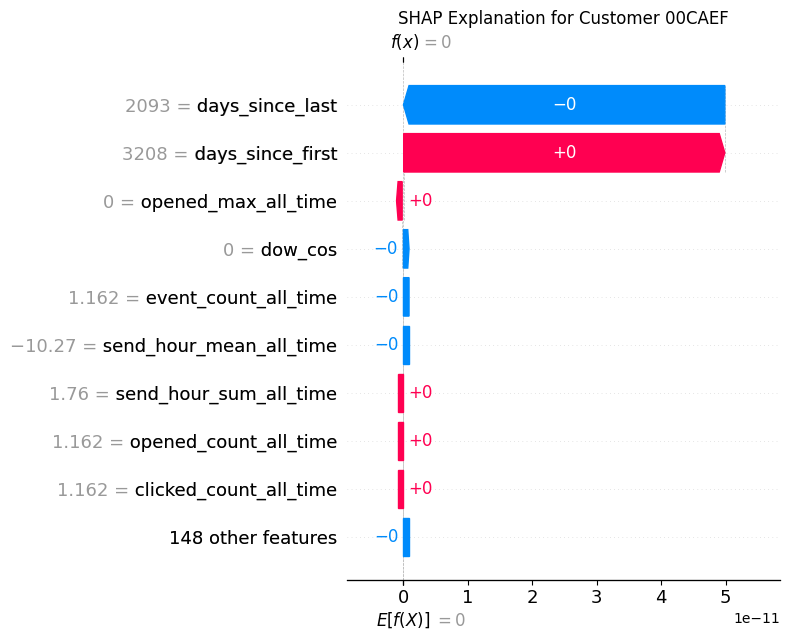



=== Customer 014D12 ===
Prediction: 0 (probability: 0.000)
Actual: 0
Correct: Yes

Top Contributing Features:


,feature,value,shap_impact
121,days_since_first,3068.000000,1.000000e-02
120,days_since_last,214.000000,-1.000000e-02
102,opened_mean_all_time,7.250272,-3.556183e-17
103,opened_max_all_time,1.000000,-8.673617e-18
114,bounced_max_all_time,1.000000,8.673617e-19
154,clicked_mean_all_time_is_zero,0.000000,-1.636693e-26
107,clicked_max_all_time,1.000000,-1.238216e-26
105,clicked_sum_all_time,0.526589,-4.650213e-27
128,event_count_365d_x_event_count_all_time,34.000000,2.117744e-27
110,send_hour_mean_all_time,-11.393266,-2.002854e-27


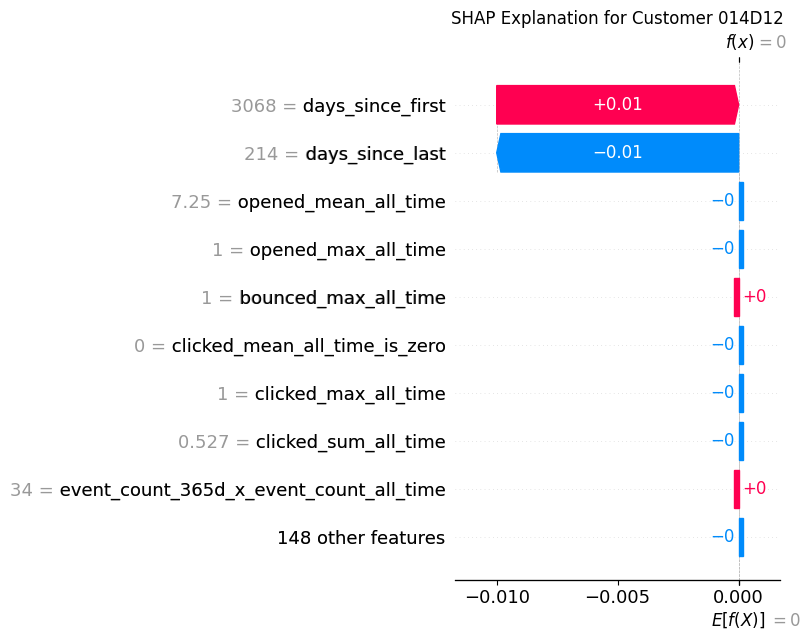

In [18]:
# Show first 3 customers
print("Showing first 3 customers:\n")
for i in range(min(3, len(browser_df))):
    show_customer(i)
    print("\n" + "=" * 60 + "\n")

In [19]:
def lookup_customer(entity_id):
    mask = browser_df[ENTITY_KEY] == entity_id
    if not mask.any():
        print(f"Customer {entity_id} not found in scoring set")
        return
    idx = browser_df[mask].index[0]
    x_idx = browser_df.index.get_loc(idx)
    show_customer(x_idx)


print("Available entity IDs (first 10):")
print(browser_df[ENTITY_KEY].head(10).tolist())

Available entity IDs (first 10):
['0091D5', '00CAEF', '014D12', '01758D', '01C2FD', '01E1D7', '0242EC', '035822', '03A263', '045255']


## 11.8 Error Analysis

In [20]:
# Analyze misclassified customers
incorrect = browser_df[browser_df["correct"] == 0]
print(f"Misclassified customers: {len(incorrect):,}")

# False positives (predicted 1, actual 0)
fp = incorrect[incorrect["prediction"] == 1]
print(f"  False Positives: {len(fp):,}")

# False negatives (predicted 0, actual 1)
fn = incorrect[incorrect["prediction"] == 0]
print(f"  False Negatives: {len(fn):,}")

Misclassified customers: 2
  False Positives: 1
  False Negatives: 1



=== Example False Positive ===
=== Customer FE7AC7 ===
Prediction: 1 (probability: 0.998)
Actual: 0
Correct: No

Top Contributing Features:


,feature,value,shap_impact
120,days_since_last,2910.000000,0.536611
121,days_since_first,2923.000000,0.266389
102,opened_mean_all_time,-13.731107,0.187483
110,send_hour_mean_all_time,-14.816482,0.006070
107,clicked_max_all_time,0.000000,0.001481
105,clicked_sum_all_time,0.000000,0.000364
128,event_count_365d_x_event_count_all_time,0.000000,-0.000250
154,clicked_mean_all_time_is_zero,1.000000,0.000153
123,dow_cos,1.035952,0.000151
109,send_hour_sum_all_time,1.474144,-0.000085


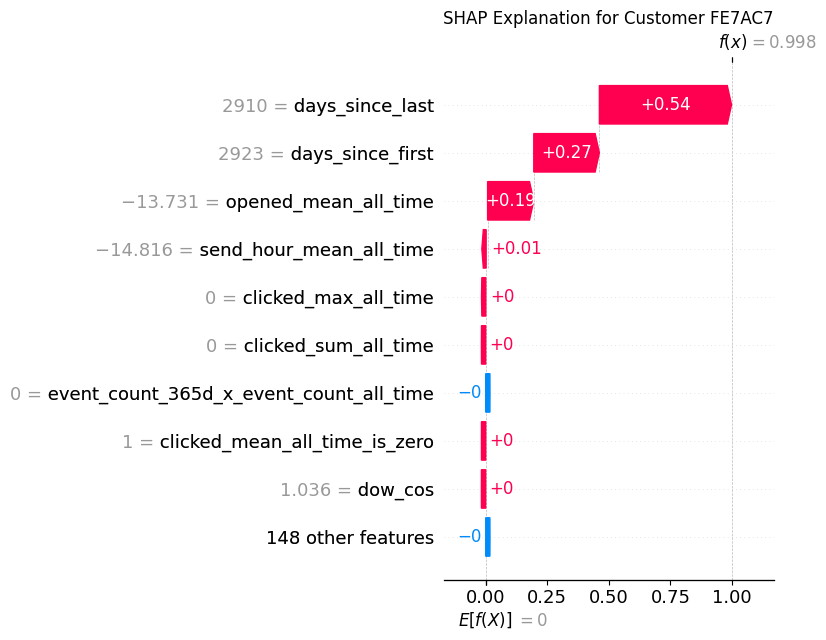

In [21]:
# Example false positive
if len(fp) > 0:
    print("\n=== Example False Positive ===")
    fp_idx = browser_df.index.get_loc(fp.index[0])
    show_customer(fp_idx)


=== Example False Negative ===
=== Customer 0C3629 ===
Prediction: 0 (probability: 0.000)
Actual: 1
Correct: No

Top Contributing Features:


,feature,value,shap_impact
120,days_since_last,3169.000000,0.423290
102,opened_mean_all_time,45.716135,-0.256204
121,days_since_first,3169.000000,-0.175407
154,clicked_mean_all_time_is_zero,1.000000,0.002233
153,clicked_sum_all_time_is_zero,1.000000,0.002160
107,clicked_max_all_time,0.000000,0.002064
123,dow_cos,1.035952,0.001422
105,clicked_sum_all_time,0.000000,0.000768
122,dow_sin,0.000000,-0.000332
110,send_hour_mean_all_time,-15.543916,0.000139


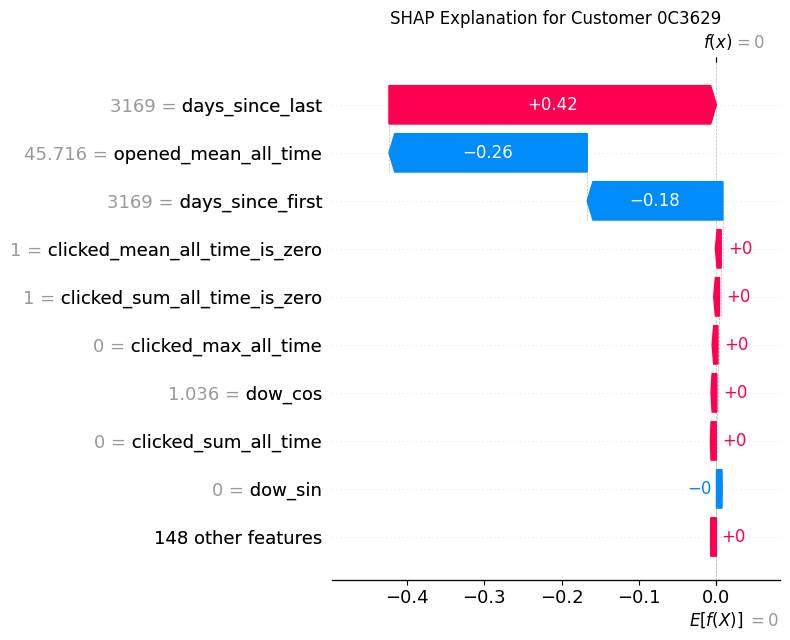

In [22]:
# Example false negative
if len(fn) > 0:
    print("\n=== Example False Negative ===")
    fn_idx = browser_df.index.get_loc(fn.index[0])
    show_customer(fn_idx)

## 11.9 Export Results

In [23]:
if is_databricks():
    from customer_retention.core.compat.detection import get_spark_session
    spark = get_spark_session()

output_dir = config.scoring_output_dir
output_dir.mkdir(parents=True, exist_ok=True)

importance_df.to_csv(output_dir / "feature_importance.csv", index=False)
print(f"Feature importance saved to {output_dir / 'feature_importance.csv'}")

top_features = importance_df.head(10)["feature"].tolist()
shap_by_entity = pd.DataFrame({ENTITY_KEY: scoring_features[ENTITY_KEY].values})
for feat in top_features:
    feat_idx = feature_names.index(feat)
    if len(shap_values.shape) == 3:
        shap_by_entity[f"shap_{feat}"] = shap_values[:, feat_idx, 1].values
    else:
        shap_by_entity[f"shap_{feat}"] = shap_values[:, feat_idx].values

detailed_df = predictions_df.merge(shap_by_entity, on=ENTITY_KEY, how="left")
detailed_df.to_parquet(output_dir / "predictions_with_shap.parquet", index=False)
print(f"Detailed predictions with SHAP saved to {output_dir / 'predictions_with_shap.parquet'}")

if is_databricks():
    table_name = f"{config.catalog}.{config.schema}.scoring_results"
    spark.createDataFrame(detailed_df).write.format("delta") \
        .mode("overwrite").saveAsTable(table_name)
    print(f"Results saved to Delta table: {table_name}")

Feature importance saved to /Users/Vital/python/CustomerRetention/experiments/data/scoring/feature_importance.csv
Detailed predictions with SHAP saved to /Users/Vital/python/CustomerRetention/experiments/data/scoring/predictions_with_shap.parquet


> **Save Reminder:** Save this notebook (Ctrl+S / Cmd+S) before running the next one.
> The next notebook will automatically export this notebook's HTML documentation from the saved file.